## Mesh resolution and timestep considerations

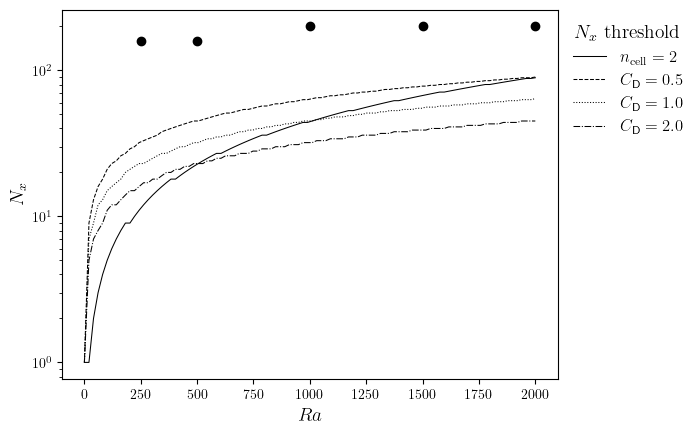

In [ ]:
import numpy as np
from lucifex.fdm import diffusive_timestep, advective_timestep
from lucifex.viz import plot_line, create_cycler
from crocodil.dns.system_a import SYSTEM_A_REFERENCE
from crocodil.dns.theory import threshold_Nx, diffusive_Nx, create_Nx_selector

Lx = 2.0
Ly = 1.0
n_per_cell = 2
courant = 1.0
courant_2 = 2 * courant

Ra_max = 2e3
Ra_axis = np.linspace(1e-2, Ra_max, num=100)
thresh_line = [threshold_Nx(Ra, Lx, Ly, n_per_cell) for Ra in Ra_axis]
cD_opts = (0.5, 1.0, 2.0)
courant_lines = [
    [diffusive_Nx(Ra, Lx, cD) for Ra in Ra_axis] for cD in cD_opts
]

fig, ax = plot_line(
    [(Ra_axis, ln) for ln in (thresh_line, *courant_lines)],
    x_label='$Ra$',
    y_label='$N_x$',
    cyc='black',
    legend_labels=[
        f'$n_{{\mathrm{{cell}}}}={n_per_cell}$', 
        *[
            f'$C_{{\mathsf{{D}}}}={cD}$'
            for cD in cD_opts
        ],
    ],
    legend_title='$N_x$ threshold',
)
ax.set_yscale('log')

Ra_ref = SYSTEM_A_REFERENCE['Ra']
Ra_opts = tuple(i * Ra_ref for i in (0.25, 0.5, 1.0, 1.5, 2.0))
Nx_selector = create_Nx_selector([160, 200], [1000.0])
Nx_selected = [Nx_selector(Ra) for Ra in Ra_opts]

cyc = create_cycler(linestyle='none', marker='o', ms=6, color='black')
plot_line(fig, ax, (Ra_opts, Nx_selected), cyc=cyc, x_lims=None)

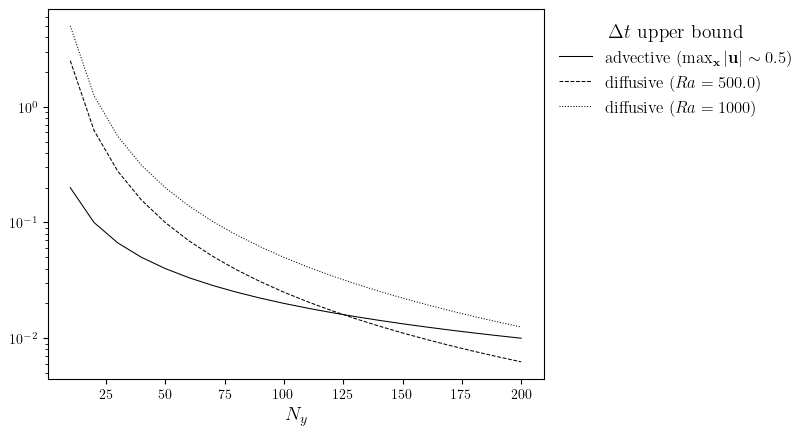

In [ ]:
uMax_estm = 0.5
Ly = 1.0
Ny_axis = range(10, 210, 10)
dtU_line = [advective_timestep(uMax_estm, Ly / Ny) for Ny in Ny_axis]
Ra_opts = (500.0, 1000.0)
dtD_lines = [
    [diffusive_timestep(1/Ra, Ly / Ny) for Ny in Ny_axis] for Ra in Ra_opts
]

fig, ax = plot_line(
    [(Ny_axis, ln) for ln in (dtU_line, *dtD_lines)],
    x_label='$N_y$',
    cyc='black',
    legend_labels=[
        f'advective ($\max_{{\mathbf{{x}}}}|\mathbf{{u}}|\sim{uMax_estm}$)', 
        *[f'diffusive ($Ra={Ra}$)' for Ra in Ra_opts], 
    ],
    legend_title='$\Delta t$ upper bound',
)
ax.set_yscale('log')